In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/housing.csv")

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print("Размер данных:", df.shape)

print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков:")
print(df.isnull().sum())

print("\nСтатистика:")
display(df.describe())

Размер данных: (20640, 10)

Типы данных:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Количество пропусков:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Статистика:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
print(df["median_house_value"].describe())

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64


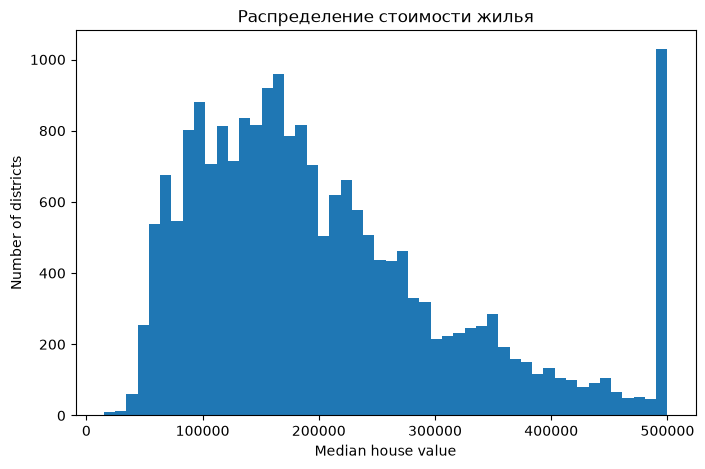

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df["median_house_value"], bins=50)
plt.xlabel("Median house value")
plt.ylabel("Number of districts")
plt.title("Распределение стоимости жилья")
plt.show()

In [6]:
print("Количество дубликатов:", df.duplicated().sum())

Количество дубликатов: 0


In [7]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

print("X:", X.shape)
print("y:", y.shape)

X: (20640, 9)
y: (20640,)


In [8]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Числовые признаки:")
print(list(numeric_features))

print("\nКатегориальные признаки:")
print(list(categorical_features))

Числовые признаки:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Категориальные признаки:
['ocean_proximity']


C:\Users\Laptop312\AppData\Local\Temp\ipykernel_9184\4202801786.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (16512, 9)
Размер X_test: (4128, 9)
Размер y_train: (16512,)
Размер y_test: (4128,)


In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [12]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [13]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [14]:
y_pred = baseline_model.predict(X_test)

print("Первые 10 прогнозов:")
print(y_pred[:10])

Первые 10 прогнозов:
[ 54261.02768976 124430.91772796 255694.95828244 268208.01035997
 262975.01360647 139811.88274638 290871.00270495 228470.45516608
 256712.36440083 408129.43722564]


In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Baseline model:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Baseline model:
MAE : 50670.48923565362
MSE : 4908290571.346432
RMSE: 70059.19333925014
R²  : 0.6254382675296266


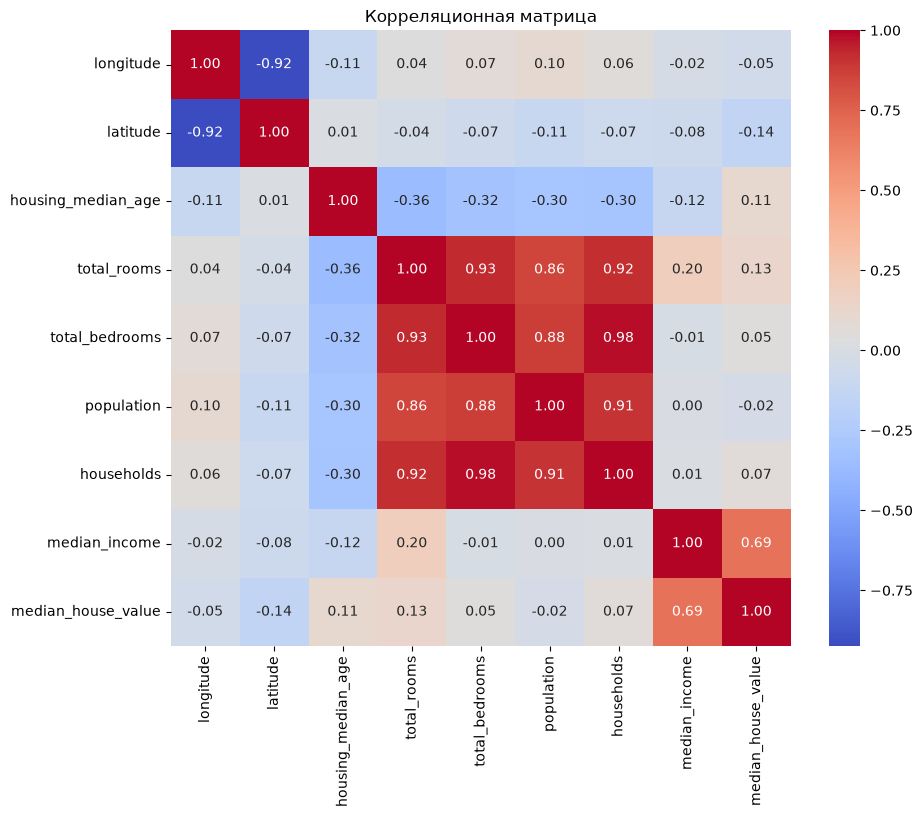

In [16]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

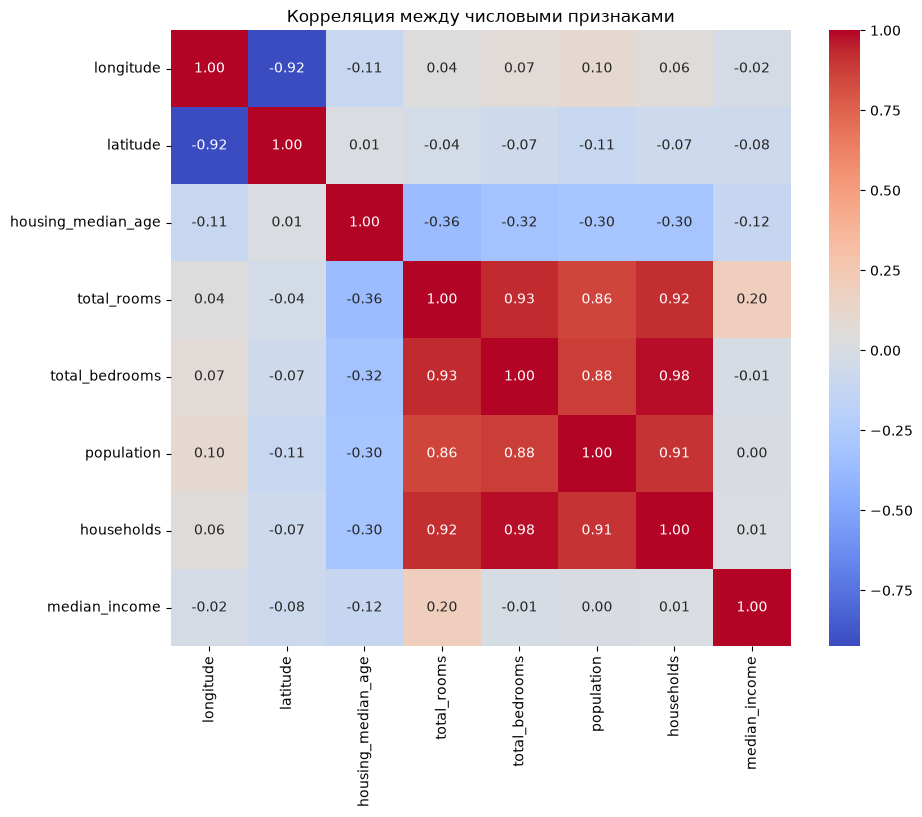

In [17]:
feature_corr = X.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция между числовыми признаками")
plt.show()

In [18]:
reduced_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "median_income",
    "ocean_proximity"
]

X_reduced = df[reduced_features]
y = df["median_house_value"]

In [19]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
numeric_features_red = X_reduced.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features_red = X_reduced.select_dtypes(
    include=["object"]
).columns

C:\Users\Laptop312\AppData\Local\Temp\ipykernel_9184\2676610922.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_red = X_reduced.select_dtypes(


In [21]:
numeric_transformer_red = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_red = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [22]:
numeric_transformer_red = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_red = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [23]:
preprocessor_red = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_red, numeric_features_red),
        ("cat", categorical_transformer_red, categorical_features_red)
    ]
)

In [24]:
reduced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_red),
        ("model", LinearRegression())
    ]
)

In [25]:
reduced_model.fit(X_train_red, y_train_red)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['longitude','latitude','housing_median_age','total_rooms','median_income', 'ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. T

In [26]:
y_pred_red = reduced_model.predict(X_test_red)

In [27]:
mae_red = mean_absolute_error(y_test_red, y_pred_red)
mse_red = mean_squared_error(y_test_red, y_pred_red)
rmse_red = np.sqrt(mse_red)
r2_red = r2_score(y_test_red, y_pred_red)

print("Reduced model:")
print("MAE :", mae_red)
print("MSE :", mse_red)
print("RMSE:", rmse_red)
print("R²  :", r2_red)

Reduced model:
MAE : 52663.96442863283
MSE : 5266354964.816085
RMSE: 72569.65595079037
R²  : 0.5981136383935901


In [28]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Reduced"],
    "MAE": [mae, mae_red],
    "MSE": [mse, mse_red],
    "RMSE": [rmse, rmse_red],
    "R2": [r2, r2_red]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Baseline,50670.489236,4.908291e+09,70059.193339,0.625438
1,Reduced,52663.964429,5.266355e+09,72569.655951,0.598114


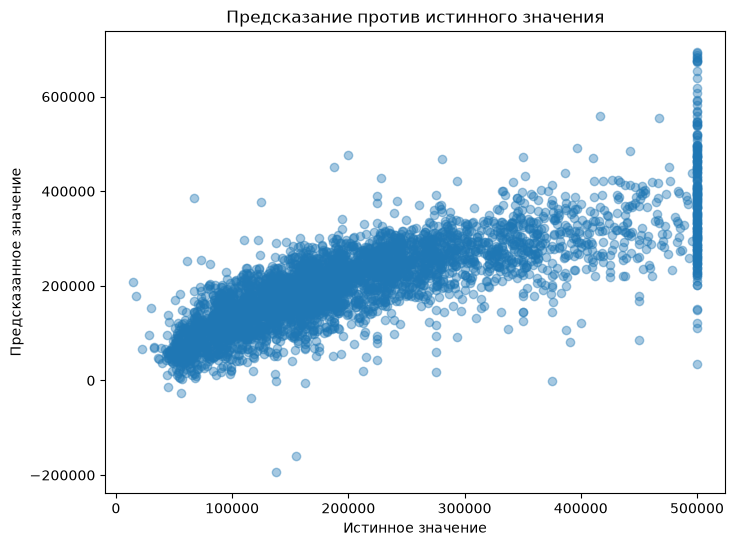

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Истинное значение")
plt.ylabel("Предсказанное значение")
plt.title("Предсказание против истинного значения")

plt.show()

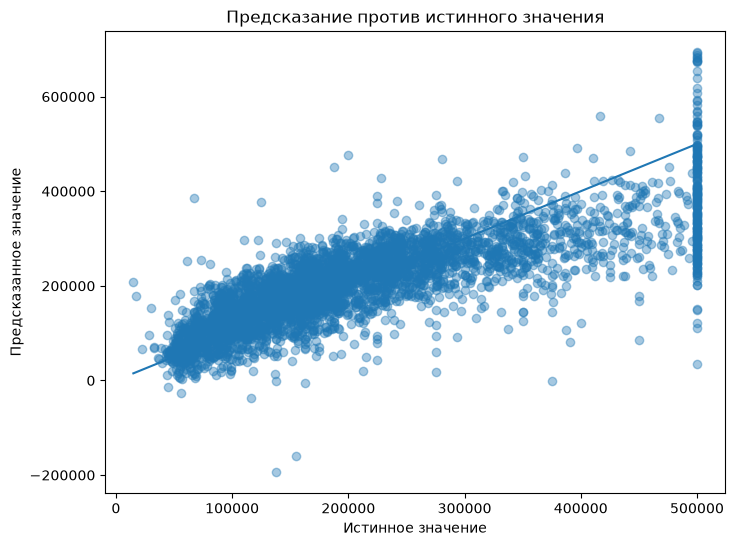

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Истинное значение")
plt.ylabel("Предсказанное значение")
plt.title("Предсказание против истинного значения")

plt.show()

In [31]:
residuals = y_test - y_pred

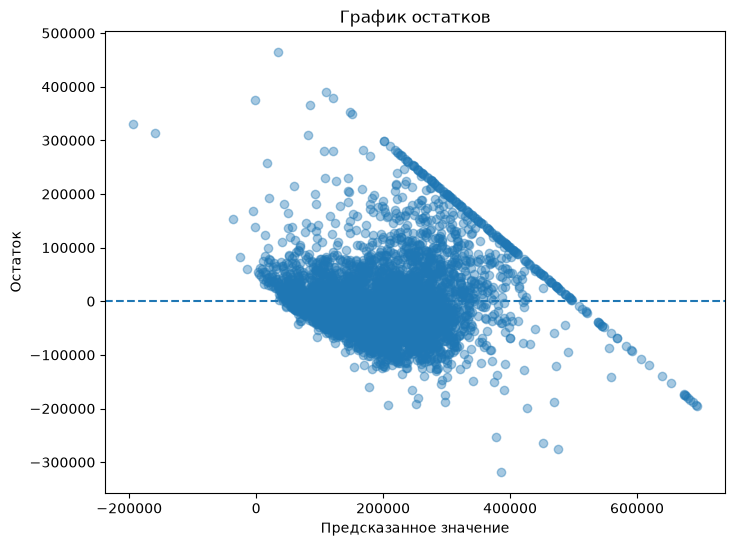

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.4)

plt.axhline(0, linestyle="--")

plt.xlabel("Предсказанное значение")
plt.ylabel("Остаток")
plt.title("График остатков")

plt.show()

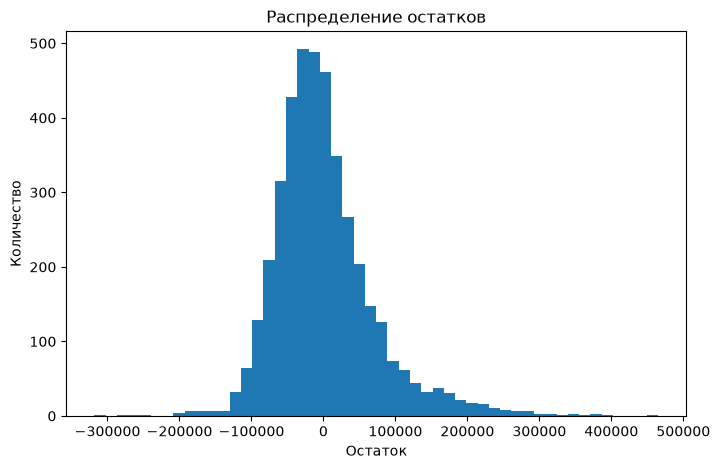

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=50)

plt.xlabel("Остаток")
plt.ylabel("Количество")
plt.title("Распределение остатков")

plt.show()

Цель

Цель работы — построить модель линейной регрессии для прогнозирования медианной стоимости жилья и сравнить модели на полном и сокращённом наборе признаков.

Данные

В работе используется California Housing Dataset, содержащий информацию о жилых районах Калифорнии. Целевой переменной является median_house_value.

Базовая модель

В базовой модели используются все доступные признаки. Для числовых признаков применяется заполнение пропусков медианой и масштабирование, а категориальный признак ocean_proximity кодируется методом One-Hot Encoding.

Мультиколлинеарность

Корреляционная матрица была использована для выявления сильно связанных числовых признаков. На основе анализа был сформирован сокращённый набор признаков.

Сравнение

Были рассчитаны MAE, MSE, RMSE и R². MAE и RMSE показывают ошибку прогнозирования в единицах стоимости жилья, а R² показывает долю вариации целевой переменной, объясняемую моделью.

Вывод

В работе была построена модель линейной регрессии для прогнозирования median_house_value. Предобработка данных выполнялась с помощью Pipeline: числовые признаки заполнялись медианой и масштабировались, а категориальный признак кодировался One-Hot Encoding.

Сначала была обучена базовая модель на полном наборе признаков. Затем с помощью корреляционной матрицы была исследована взаимосвязь между числовыми признаками и сформирован сокращённый набор признаков.

Для обеих моделей были рассчитаны MAE, MSE, RMSE и R². MAE и RMSE позволяют оценить величину ошибки непосредственно в единицах стоимости жилья.

Также были построены графики предсказанных и истинных значений и график остатков. По графику остатков можно оценить наличие систематического паттерна ошибок.

Финальный набор признаков выбран на основе сравнения качества моделей на тестовой выборке и анализа мультиколлинеарности.

### Сравнение моделей

Базовая модель использует все доступные признаки, а сокращённая модель — уменьшенный набор признаков после анализа корреляционной матрицы.

В результате базовая модель показала MAE = 50 670, RMSE = 70 059 и R² = 0.625. Это означает, что средняя абсолютная ошибка прогноза составляет примерно 50,7 тыс. единиц стоимости жилья, а модель объясняет около 62,5% вариации целевой переменной на тестовой выборке.

Для сокращённой модели MAE составил 52 664, RMSE — 72 570, а R² — 0.598. Таким образом, после сокращения признаков качество модели снизилось.

На основании результатов тестовой выборки в качестве финальной выбрана базовая модель с полным набором признаков.

### Анализ остатков

На графике распределения остатков видно, что большая часть ошибок сосредоточена около нулевого значения. Это означает, что для большинства объектов разница между истинным и предсказанным значением относительно небольшая.

При этом распределение остатков не является полностью симметричным и имеет выраженный правый хвост. Наблюдаются отдельные большие положительные остатки, что указывает на случаи, когда модель существенно занижает стоимость жилья.

Таким образом, ошибки модели не полностью случайны, и линейная модель не может одинаково хорошо описывать все значения целевой переменной.

## Итоговый вывод

В ходе практической работы была построена модель линейной регрессии для прогнозирования медианной стоимости жилья в районах Калифорнии.

Для предобработки данных использовался Pipeline: числовые признаки заполнялись медианой и масштабировались, а категориальный признак `ocean_proximity` преобразовывался с помощью One-Hot Encoding.

Анализ корреляционной матрицы показал наличие сильной мультиколлинеарности между некоторыми признаками. Например, корреляция между `total_bedrooms` и `households` составляет 0.98, а между `total_rooms` и `total_bedrooms` — 0.93.

Были сравнены базовая модель со всеми признаками и модель с сокращённым набором признаков. Базовая модель показала MAE = 50 670, RMSE = 70 059 и R² = 0.625. Для сокращённой модели MAE = 52 664, RMSE = 72 570 и R² = 0.598.

Таким образом, сокращение выбранных признаков привело к снижению качества модели на тестовой выборке. Поэтому в качестве финальной модели выбран полный набор признаков.

Анализ остатков показал, что большинство ошибок сосредоточено около нуля, однако распределение имеет выраженный правый хвост и отдельные большие ошибки. Это показывает, что линейная модель не одинаково хорошо описывает все значения стоимости жилья.